# Phase 3B.3 - Final 20-Stimulus Acoustic Feature Exploration

This notebook documents the objective acoustic predictors for the final 5-mix / 3-context study design. It does not fit a Bayesian rating model. Its purpose is to determine the final primary acoustic predictor set for Phase 3B.4.

## 1. Imports and Repository-Relative Paths

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.plotting import scatter_matrix

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
RANDOM_SEED = 42

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    markers = [
        Path("statistical-baseline/data/synthetic/final_5mix_stimulus_metadata_seed42.csv"),
        Path("outputs/stimulus_selection/11_five_mix_selection_review_20260806/five_mix_selection_traceability.csv"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()
SYNTHETIC_DIR = REPO_ROOT / "statistical-baseline" / "data" / "synthetic"
OUTPUT_DIR = REPO_ROOT / "statistical-baseline" / "outputs" / "feature_exploration"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = SYNTHETIC_DIR / "final_5mix_stimulus_metadata_seed42.csv"
FEATURE_V2_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "processed_features_v2.csv"
FEATURE_BACKUP_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "08_backup_song_expansion" / "04_acoustic_candidate_pools" / "tables" / "processed_features_backup.csv"
TRACEABILITY_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "11_five_mix_selection_review_20260806" / "five_mix_selection_traceability.csv"
FEATURE_SCHEMA_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "feature_schema.json"
V2_METHOD_CHANGE_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "reports" / "v1_to_v2_method_change.md"
DIVERSITY_ASSERTIONS_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tests_and_validation" / "diversity_feature_assertions.csv"
BARK_PCA_VARIANCE_V2_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "bark_pca_explained_variance_v2.csv"
POOL_SUMMARY_V2_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection_v2" / "tables" / "acoustic_candidate_pool_summary.csv"

path_table = pd.DataFrame([
    {"label": "final_metadata", "path": METADATA_PATH.relative_to(REPO_ROOT), "exists": METADATA_PATH.exists()},
    {"label": "processed_features_v2", "path": FEATURE_V2_PATH.relative_to(REPO_ROOT), "exists": FEATURE_V2_PATH.exists()},
    {"label": "processed_features_backup", "path": FEATURE_BACKUP_PATH.relative_to(REPO_ROOT), "exists": FEATURE_BACKUP_PATH.exists()},
    {"label": "traceability", "path": TRACEABILITY_PATH.relative_to(REPO_ROOT), "exists": TRACEABILITY_PATH.exists()},
    {"label": "feature_schema", "path": FEATURE_SCHEMA_PATH.relative_to(REPO_ROOT), "exists": FEATURE_SCHEMA_PATH.exists()},
    {"label": "v2_method_change", "path": V2_METHOD_CHANGE_PATH.relative_to(REPO_ROOT), "exists": V2_METHOD_CHANGE_PATH.exists()},
    {"label": "diversity_assertions", "path": DIVERSITY_ASSERTIONS_PATH.relative_to(REPO_ROOT), "exists": DIVERSITY_ASSERTIONS_PATH.exists()},
    {"label": "output_dir", "path": OUTPUT_DIR.relative_to(REPO_ROOT), "exists": OUTPUT_DIR.exists()},
])
path_table

,label,path,exists
0,final_metadata,statistical-baseline\data\synthetic\final_5mix...,True
1,processed_features_v2,outputs\stimulus_selection\04_mix_selection_v2...,True
2,processed_features_backup,outputs\stimulus_selection\08_backup_song_expa...,True
3,traceability,outputs\stimulus_selection\11_five_mix_selecti...,True
4,feature_schema,outputs\stimulus_selection\03_feature_extracti...,True
5,v2_method_change,outputs\stimulus_selection\04_mix_selection_v2...,True
6,diversity_assertions,outputs\stimulus_selection\04_mix_selection_v2...,True
7,output_dir,statistical-baseline\outputs\feature_exploration,True


## 2. Load the Final 20-Stimulus Feature Table

In [2]:
stimuli = pd.read_csv(METADATA_PATH)
features_v2 = pd.read_csv(FEATURE_V2_PATH)
features_backup = pd.read_csv(FEATURE_BACKUP_PATH)
traceability = pd.read_csv(TRACEABILITY_PATH)
diversity_assertions = pd.read_csv(DIVERSITY_ASSERTIONS_PATH) if DIVERSITY_ASSERTIONS_PATH.exists() else pd.DataFrame()
bark_pca_variance_v2 = pd.read_csv(BARK_PCA_VARIANCE_V2_PATH) if BARK_PCA_VARIANCE_V2_PATH.exists() else pd.DataFrame()
pool_summary_v2 = pd.read_csv(POOL_SUMMARY_V2_PATH) if POOL_SUMMARY_V2_PATH.exists() else pd.DataFrame()
feature_schema = json.loads(FEATURE_SCHEMA_PATH.read_text(encoding="utf-8")) if FEATURE_SCHEMA_PATH.exists() else {}
v2_method_change_text = V2_METHOD_CHANGE_PATH.read_text(encoding="utf-8") if V2_METHOD_CHANGE_PATH.exists() else ""

RAW_FEATURES = ["rms_mean", "crest_factor_mean", "stereo_width", "stereo_imbalance"]
Z_FEATURES = ["z_RMS", "z_CF", "z_SW", "z_SI"]
PRIMARY_FEATURES = ["z_RMS", "z_CF", "z_SW"]
SENSITIVITY_FEATURES = ["z_RMS", "z_CF", "z_SW", "z_SI"]

display(stimuli[["group", "song_id", "song_title", "mix_id", "stimulus_id", "original_mix_name", *RAW_FEATURES, *Z_FEATURES]].sort_values(["group", "song_id", "original_mix_name"]))

,group,song_id,song_title,mix_id,stimulus_id,original_mix_name,rms_mean,crest_factor_mean,stereo_width,stereo_imbalance,z_RMS,z_CF,z_SW,z_SI
7,group_01,id_like_to_know,I'd Like To Know,mix_9ffcd672af17,id_like_to_know_pxl_s1,PXL-S1,0.056513,16.363316,0.066817,0.060797,-0.565911,-0.579304,-0.485121,1.357248
8,group_01,id_like_to_know,I'd Like To Know,mix_6f8b655d7999,id_like_to_know_pxl_s2,PXL-S2,0.061623,14.764206,0.049424,0.022453,0.533000,-1.187467,-0.763752,0.551037
5,group_01,id_like_to_know,I'd Like To Know,mix_65f41f41d3ab,id_like_to_know_pxl_s3,PXL-S3,0.060649,15.086064,0.024367,-0.008429,0.323484,-1.065060,-1.165177,-0.098248
6,group_01,id_like_to_know,I'd Like To Know,mix_82d60d7c7fc5,id_like_to_know_pxl_s5,PXL-S5,0.057478,17.484858,0.146867,0.073631,-0.358338,-0.152766,0.797271,1.627075
9,group_01,id_like_to_know,I'd Like To Know,mix_b393d3919c78,id_like_to_know_pxl_s7,PXL-S7,0.055112,16.259357,0.076943,-0.053767,-0.867056,-0.618841,-0.322901,-1.051511
0,group_01,lead_me,Lead Me,mix_f1f7973e5bac,lead_me_du_d,DU-D,0.062587,13.814332,0.117577,-0.052133,0.740286,-1.548717,0.328048,-1.017147
1,group_01,lead_me,Lead Me,mix_271852ba8676,lead_me_du_e,DU-E,0.054377,19.253822,0.043004,0.043613,-1.025058,0.519995,-0.866608,0.995934
4,group_01,lead_me,Lead Me,mix_d3e3580b6e30,lead_me_mcg_pro2,McG-pro2,0.073005,20.146322,0.039276,-0.001436,2.980531,0.859425,-0.926328,0.048774
2,group_01,lead_me,Lead Me,mix_d5b28dfc8a93,lead_me_pxl_l1,PXL-L1,0.059133,16.919521,0.017093,-0.012909,-0.002444,-0.367771,-1.281694,-0.192446
3,group_01,lead_me,Lead Me,mix_c7d9a071ba25,lead_me_pxl_l4,PXL-L4,0.058888,15.674652,0.149042,0.109931,-0.055201,-0.841212,0.832111,2.390300


## 3. Validate Final Feature Coverage

In [3]:
validation_rows = []
def add_check(check, observed, expected, passed=None):
    if passed is None:
        passed = observed == expected
    validation_rows.append({"check": check, "observed": observed, "expected": expected, "passed": bool(passed)})

add_check("Exactly 20 stimuli", stimuli["stimulus_id"].nunique(), 20)
add_check("Exactly 4 songs", stimuli["song_id"].nunique(), 4)
add_check("Exactly 5 mixes per song", stimuli.groupby("song_id")["mix_id"].nunique().to_dict(), "all songs have 5", (stimuli.groupby("song_id")["mix_id"].nunique() == 5).all())
add_check("Exactly 2 groups", stimuli["group"].nunique(), 2)
add_check("No duplicate stimulus_id", int(stimuli["stimulus_id"].duplicated().sum()), 0)
for col in PRIMARY_FEATURES:
    add_check(f"Complete {col}", int(stimuli[col].notna().sum()), 20)
add_check("Complete z_SI", int(stimuli["z_SI"].notna().sum()), 20)
add_check("Complete group/song/mix/stimulus mapping", "complete", "complete", stimuli[["group", "song_id", "mix_id", "stimulus_id"]].notna().all().all())

validation_summary = pd.DataFrame(validation_rows)
display(validation_summary)
if not validation_summary["passed"].all():
    raise AssertionError("Feature-table validation failed.")

,check,observed,expected,passed
0,Exactly 20 stimuli,20,20,True
1,Exactly 4 songs,4,4,True
2,Exactly 5 mixes per song,"{'id_like_to_know': 5, 'in_the_meantime': 5, '...",all songs have 5,True
3,Exactly 2 groups,2,2,True
4,No duplicate stimulus_id,0,0,True
5,Complete z_RMS,20,20,True
6,Complete z_CF,20,20,True
7,Complete z_SW,20,20,True
8,Complete z_SI,20,20,True
9,Complete group/song/mix/stimulus mapping,complete,complete,True


## 4. Verify Joint Standardisation

In [4]:
z_feature_validation = (
    stimuli[Z_FEATURES]
    .agg(["mean", lambda x: x.std(ddof=0), "min", "max"])
    .rename(index={"<lambda>": "population_sd"})
    .T.reset_index(names="feature")
)
z_feature_validation["mean_approx_zero"] = np.isclose(z_feature_validation["mean"], 0, atol=1e-10)
z_feature_validation["population_sd_approx_one"] = np.isclose(z_feature_validation["population_sd"], 1, atol=1e-10)
z_feature_validation["jointly_standardised_final20"] = z_feature_validation["mean_approx_zero"] & z_feature_validation["population_sd_approx_one"]
z_feature_validation

,feature,mean,population_sd,min,max,mean_approx_zero,population_sd_approx_one,jointly_standardised_final20
0,z_RMS,7.410739e-16,1.0,-1.899007,2.980531,True,True,True
1,z_CF,-1.409983e-15,1.0,-1.548717,1.918719,True,True,True
2,z_SW,-5.828671e-17,1.0,-1.546820,1.926896,True,True,True
3,z_SI,4.996004e-17,1.0,-1.263072,2.390300,True,True,True


## 5. Raw Feature Summaries and Usable Variation

In [5]:
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)
feature_summary = (
    stimuli[RAW_FEATURES]
    .agg(["count", "mean", "std", "min", q1, "median", q3, "max"])
    .rename(index={"q1": "q1", "q3": "q3"})
    .T.reset_index(names="feature")
)
feature_variation = []
for raw, z in zip(RAW_FEATURES, Z_FEATURES):
    vals = stimuli[raw].dropna()
    zvals = stimuli[z].dropna()
    iqr = vals.quantile(0.75) - vals.quantile(0.25)
    outliers = int(((zvals.abs()) >= 3).sum())
    feature_variation.append({
        "feature": raw,
        "range": vals.max() - vals.min(),
        "iqr": iqr,
        "population_sd": vals.std(ddof=0),
        "near_zero_variance": bool(vals.std(ddof=0) < 1e-8),
        "absolute_z_ge_3_count": outliers,
        "restricted_range_flag": bool(iqr < 1e-8),
        "usable_for_modelling": bool(vals.std(ddof=0) >= 1e-8 and iqr >= 1e-8),
    })
feature_variation = pd.DataFrame(feature_variation)
display(feature_summary)
display(feature_variation)

,feature,count,mean,std,min,q1,median,q3,max
0,rms_mean,20.0,0.059144,0.004771,0.050313,0.056023,0.059010,0.061332,0.073005
1,crest_factor_mean,20.0,17.886542,2.697716,13.814332,16.113181,17.425607,19.990781,22.931637
2,stereo_width,20.0,0.097099,0.064044,0.000544,0.042961,0.078236,0.147440,0.217380
3,stereo_imbalance,20.0,-0.003756,0.048797,-0.063830,-0.046278,-0.010669,0.025692,0.109931


,feature,range,iqr,population_sd,near_zero_variance,absolute_z_ge_3_count,restricted_range_flag,usable_for_modelling
0,rms_mean,0.022692,0.005309,0.004650,False,0,False,True
1,crest_factor_mean,9.117305,3.877600,2.629408,False,0,False,True
2,stereo_width,0.216837,0.104480,0.062422,False,0,False,True
3,stereo_imbalance,0.173761,0.071970,0.047562,False,0,False,True


## 6. Correlation Analysis Across the 20 Unique Stimuli

In [6]:
pearson_corr = stimuli[Z_FEATURES].corr(method="pearson")
spearman_corr = stimuli[Z_FEATURES].corr(method="spearman")

def strongest_correlations(corr, method):
    rows = []
    cols = list(corr.columns)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            r = float(corr.loc[a, b])
            rows.append({
                "method": method,
                "feature_a": a,
                "feature_b": b,
                "correlation": r,
                "abs_correlation": abs(r),
                "flag": "very strong" if abs(r) >= 0.90 else ("potentially strong" if abs(r) >= 0.70 else ""),
            })
    return pd.DataFrame(rows).sort_values("abs_correlation", ascending=False)

strongest_pearson = strongest_correlations(pearson_corr, "pearson")
strongest_spearman = strongest_correlations(spearman_corr, "spearman")
display(pearson_corr)
display(spearman_corr)
display(strongest_pearson)
display(strongest_spearman)

,z_RMS,z_CF,z_SW,z_SI
z_RMS,1.000000,-0.148135,-0.260087,-0.089396
z_CF,-0.148135,1.000000,0.136606,-0.098026
z_SW,-0.260087,0.136606,1.000000,-0.150701
z_SI,-0.089396,-0.098026,-0.150701,1.000000


,z_RMS,z_CF,z_SW,z_SI
z_RMS,1.000000,-0.209023,-0.276692,-0.166917
z_CF,-0.209023,1.000000,0.136842,0.024060
z_SW,-0.276692,0.136842,1.000000,-0.209023
z_SI,-0.166917,0.024060,-0.209023,1.000000


,method,feature_a,feature_b,correlation,abs_correlation,flag
1,pearson,z_RMS,z_SW,-0.260087,0.260087,
5,pearson,z_SW,z_SI,-0.150701,0.150701,
0,pearson,z_RMS,z_CF,-0.148135,0.148135,
3,pearson,z_CF,z_SW,0.136606,0.136606,
4,pearson,z_CF,z_SI,-0.098026,0.098026,
2,pearson,z_RMS,z_SI,-0.089396,0.089396,


,method,feature_a,feature_b,correlation,abs_correlation,flag
1,spearman,z_RMS,z_SW,-0.276692,0.276692,
0,spearman,z_RMS,z_CF,-0.209023,0.209023,
5,spearman,z_SW,z_SI,-0.209023,0.209023,
2,spearman,z_RMS,z_SI,-0.166917,0.166917,
3,spearman,z_CF,z_SW,0.136842,0.136842,
4,spearman,z_CF,z_SI,0.024060,0.024060,


## 7. Song- and Group-Specific Structure

In [7]:
feature_by_song_summary = (
    stimuli.groupby(["song_id", "song_title"], as_index=False)[Z_FEATURES]
    .agg(["mean", "min", "max", "std"])
)
feature_by_song_summary.columns = ["_".join(col).rstrip("_") for col in feature_by_song_summary.columns.to_flat_index()]

feature_by_group_summary = (
    stimuli.groupby("group", as_index=False)[Z_FEATURES]
    .agg(["mean", "min", "max", "std"])
)
feature_by_group_summary.columns = ["_".join(col).rstrip("_") for col in feature_by_group_summary.columns.to_flat_index()]

song_between_within_rows = []
for feature in Z_FEATURES:
    song_means = stimuli.groupby("song_id")[feature].mean()
    within_sds = stimuli.groupby("song_id")[feature].std(ddof=0)
    song_between_within_rows.append({
        "feature": feature,
        "between_song_mean_range": float(song_means.max() - song_means.min()),
        "mean_within_song_sd": float(within_sds.mean()),
        "overall_sd": float(stimuli[feature].std(ddof=0)),
        "dominant_pattern": "between-song prominent" if (song_means.max() - song_means.min()) > within_sds.mean() else "within-song prominent",
    })
song_between_within = pd.DataFrame(song_between_within_rows)

group_balance_rows = []
for feature in Z_FEATURES:
    means = stimuli.groupby("group")[feature].mean()
    group_balance_rows.append({
        "feature": feature,
        "group_01_mean": float(means.get("group_01", np.nan)),
        "group_02_mean": float(means.get("group_02", np.nan)),
        "absolute_group_mean_difference": float(abs(means.get("group_01", np.nan) - means.get("group_02", np.nan))),
        "imbalance_flag": bool(abs(means.get("group_01", np.nan) - means.get("group_02", np.nan)) >= 0.70),
    })
group_balance = pd.DataFrame(group_balance_rows)

display(feature_by_song_summary)
display(feature_by_group_summary)
display(song_between_within)
display(group_balance)

,song_id,song_title,z_RMS_mean,z_RMS_min,z_RMS_max,z_RMS_std,z_CF_mean,z_CF_min,z_CF_max,z_CF_std,z_SW_mean,z_SW_min,z_SW_max,z_SW_std,z_SI_mean,z_SI_min,z_SI_max,z_SI_std
0,id_like_to_know,I'd Like To Know,-0.186964,-0.867056,0.533000,0.594643,-0.720688,-1.187467,-0.152766,0.415142,-0.387936,-1.165177,0.797271,0.735481,0.477120,-1.051511,1.627075,1.092045
1,in_the_meantime,In The Meantime,-0.735009,-1.899007,0.688721,0.940395,0.469994,-1.434634,1.918719,1.410569,0.189555,-1.546820,1.851101,1.381313,-0.020548,-0.732535,0.823443,0.695134
2,lead_me,Lead Me,0.527623,-1.025058,2.980531,1.507768,-0.275656,-1.548717,0.859425,0.983679,-0.382894,-1.281694,0.832111,0.910881,0.445083,-1.017147,2.390300,1.302778
3,pouring_room,Pouring Room,0.394350,-0.081437,1.177821,0.476792,0.526350,-0.521538,1.123830,0.709706,0.581275,-0.353404,1.926896,0.939518,-0.901655,-1.263072,-0.480130,0.279397


,group,z_RMS_mean,z_RMS_min,z_RMS_max,z_RMS_std,z_CF_mean,z_CF_min,z_CF_max,z_CF_std,z_SW_mean,z_SW_min,z_SW_max,z_SW_std,z_SI_mean,z_SI_min,z_SI_max,z_SI_std
0,group_01,0.170329,-1.025058,2.980531,1.144282,-0.498172,-1.548717,0.859425,0.749444,-0.385415,-1.281694,0.832111,0.780499,0.461101,-1.051511,2.390300,1.133418
1,group_02,-0.170329,-1.899007,1.177821,0.921069,0.498172,-1.434634,1.918719,1.053117,0.385415,-1.546820,1.926896,1.132671,-0.461101,-1.263072,0.823443,0.681988


,feature,between_song_mean_range,mean_within_song_sd,overall_sd,dominant_pattern
0,z_RMS,1.262631,0.787006,1.0,between-song prominent
1,z_CF,1.247038,0.786894,1.0,between-song prominent
2,z_SW,0.969212,0.887091,1.0,between-song prominent
3,z_SI,1.378775,0.753410,1.0,between-song prominent


,feature,group_01_mean,group_02_mean,absolute_group_mean_difference,imbalance_flag
0,z_RMS,0.170329,-0.170329,0.340659,False
1,z_CF,-0.498172,0.498172,0.996344,True
2,z_SW,-0.385415,0.385415,0.770831,True
3,z_SI,0.461101,-0.461101,0.922203,True


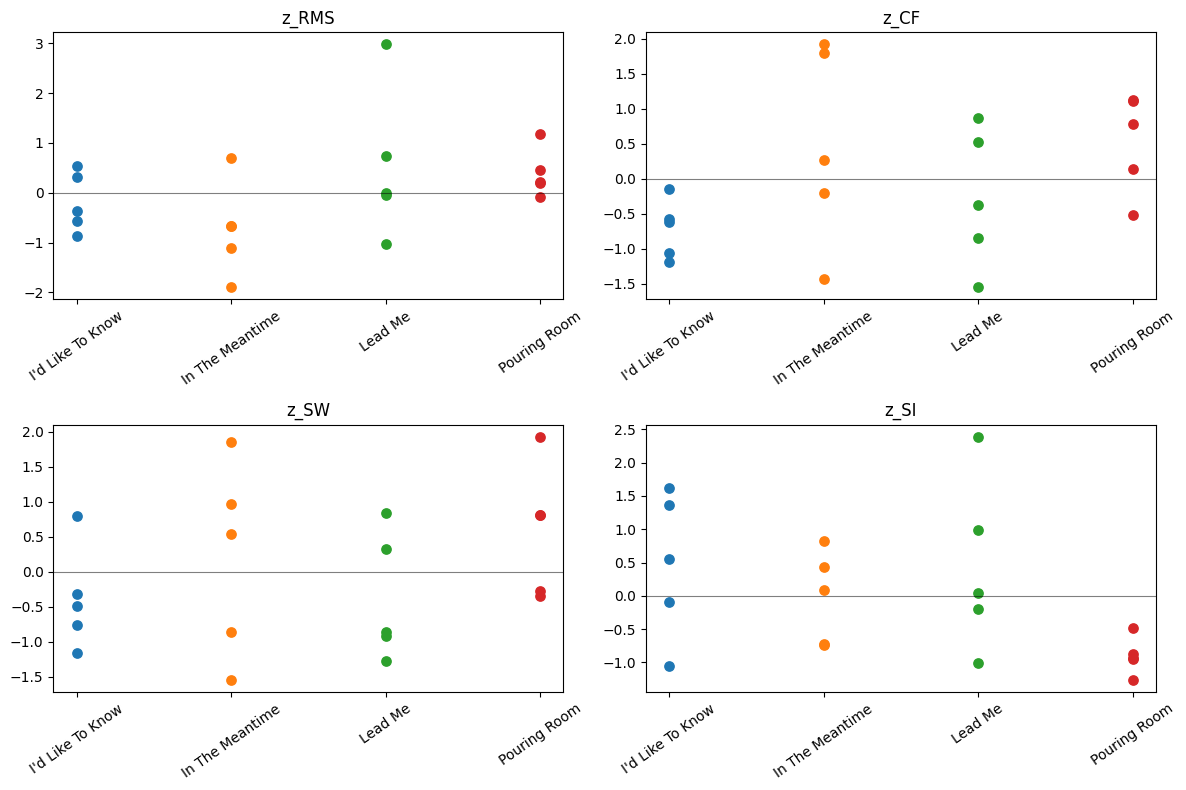

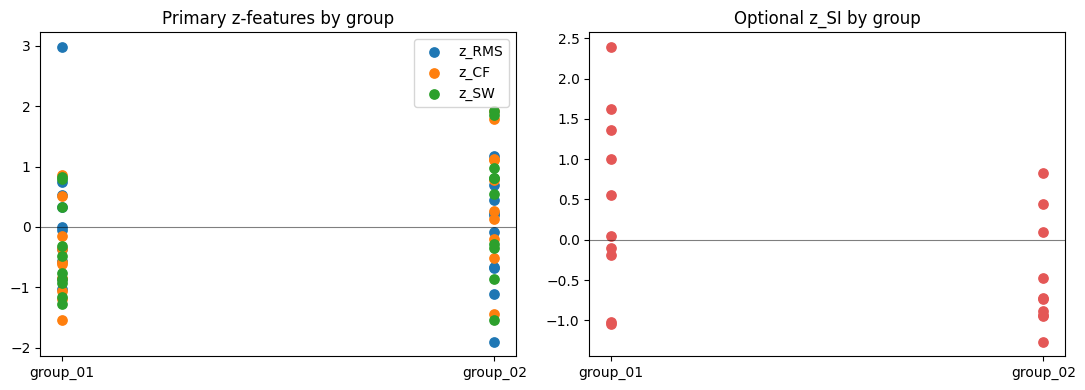

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, feature in zip(axes.ravel(), Z_FEATURES):
    for song, subset in stimuli.groupby("song_title"):
        x = np.arange(len(subset))
        ax.scatter([song] * len(subset), subset[feature], label=song, s=45)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_by_song.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for feature in PRIMARY_FEATURES:
    axes[0].scatter(stimuli["group"], stimuli[feature], label=feature, s=45)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Primary z-features by group")
axes[0].legend()
axes[1].scatter(stimuli["group"], stimuli["z_SI"], color="#E45756", s=45)
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_title("Optional z_SI by group")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "features_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Stimulus-Space Visualisation

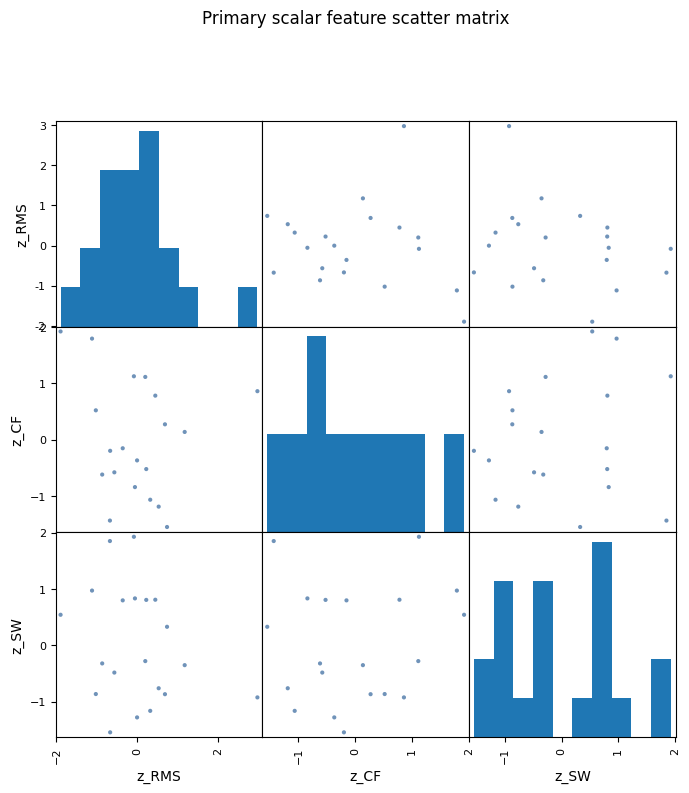

,component,explained_variance_ratio,cumulative_explained_variance
0,scalar_pc1,0.347646,0.347646
1,scalar_pc2,0.270193,0.617839
2,scalar_pc3,0.220103,0.837942
3,scalar_pc4,0.162058,1.000000


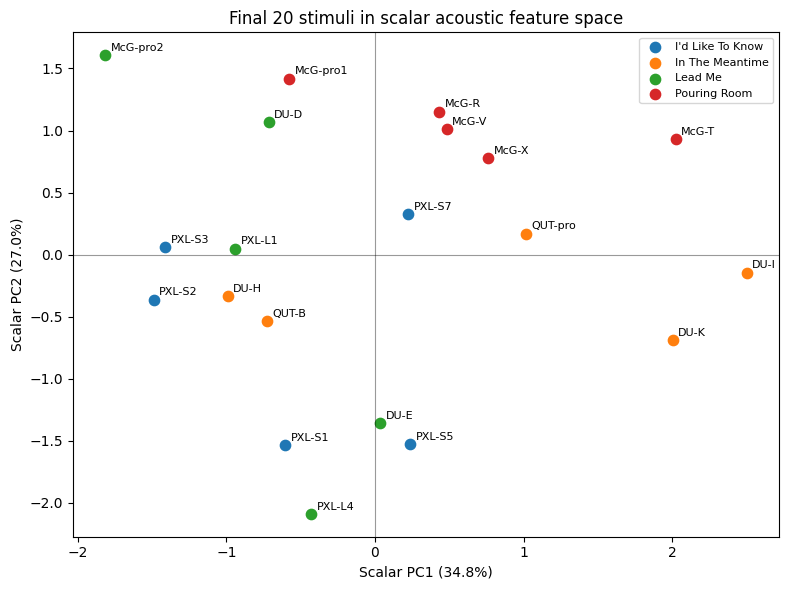

In [9]:
scatter_matrix(stimuli[PRIMARY_FEATURES], figsize=(8, 8), diagonal="hist", color="#4C78A8", alpha=0.8)
plt.suptitle("Primary scalar feature scatter matrix", y=1.02)
plt.savefig(FIGURE_DIR / "primary_feature_scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

X = stimuli[Z_FEATURES].to_numpy(dtype=float)
X_centered = X - X.mean(axis=0)
u, s, vt = np.linalg.svd(X_centered, full_matrices=False)
pca_scores = X_centered @ vt.T
explained = (s ** 2) / np.sum(s ** 2)
pca_visualisation = stimuli[["group", "song_id", "song_title", "stimulus_id", "original_mix_name"]].copy()
pca_visualisation["scalar_pc1"] = pca_scores[:, 0]
pca_visualisation["scalar_pc2"] = pca_scores[:, 1]
pca_explained = pd.DataFrame({
    "component": [f"scalar_pc{i+1}" for i in range(len(explained))],
    "explained_variance_ratio": explained,
    "cumulative_explained_variance": np.cumsum(explained),
})
display(pca_explained)

fig, ax = plt.subplots(figsize=(8, 6))
for song, subset in pca_visualisation.groupby("song_title"):
    ax.scatter(subset["scalar_pc1"], subset["scalar_pc2"], label=song, s=55)
    for _, row in subset.iterrows():
        ax.annotate(row["original_mix_name"], (row["scalar_pc1"], row["scalar_pc2"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_xlabel(f"Scalar PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"Scalar PC2 ({explained[1]:.1%})")
ax.set_title("Final 20 stimuli in scalar acoustic feature space")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "scalar_feature_pca_final20.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Bark-Spectrum Audit

In [10]:
bark_cols = [c for c in features_v2.columns if c.startswith("bark_mid_") or c.startswith("bark_side_")]
backup_bark_cols = [c for c in features_backup.columns if c.startswith("bark_mid_") or c.startswith("bark_side_")]
combined_bark = pd.concat([
    features_v2[["mix_id", "song", *bark_cols]].assign(feature_source="processed_features_v2"),
    features_backup[["mix_id", "song", *backup_bark_cols]].assign(feature_source="processed_features_backup"),
], ignore_index=True)
final_bark = stimuli[["mix_id", "stimulus_id", "song_title"]].merge(combined_bark, on="mix_id", how="left")
final_bark_cols = [c for c in final_bark.columns if c.startswith("bark_mid_") or c.startswith("bark_side_")]

main_pca_cols = [c for c in features_v2.columns if c.startswith("bark_pc_")]
backup_pca_cols = [c for c in features_backup.columns if c.startswith("bark_pc_")]
bark_audit = pd.DataFrame([
    {"item": "raw_bark_band_columns_in_main_source", "value": len(bark_cols)},
    {"item": "raw_bark_band_columns_in_backup_source", "value": len(backup_bark_cols)},
    {"item": "final_stimuli_with_complete_48_raw_bark_bands", "value": int(final_bark[final_bark_cols].notna().all(axis=1).sum())},
    {"item": "main_source_bark_pc_columns", "value": len(main_pca_cols)},
    {"item": "backup_source_bark_pc_columns", "value": len(backup_pca_cols)},
    {"item": "v2_bark_pca_songs", "value": " | ".join(sorted(bark_pca_variance_v2["song"].unique())) if not bark_pca_variance_v2.empty else "not found"},
])
bark_recommendation = {
    "recommendation": "exclude_from_primary_model",
    "reason": "Complete raw 48-band Bark information exists for all final stimuli, but existing Bark PCA columns are not one globally fitted representation across the final 20 stimuli. The v2 PCA is song-specific; the backup source has fewer PCA columns and was generated separately. No scalar Bark predictor should be invented for the primary model.",
    "sensitivity_analysis": "A later sensitivity analysis could derive and freeze a single global low-dimensional Bark representation across all final 20 stimuli, but this notebook does not recompute it.",
}
display(bark_audit)
display(pd.DataFrame([bark_recommendation]))

,item,value
0,raw_bark_band_columns_in_main_source,48
1,raw_bark_band_columns_in_backup_source,48
2,final_stimuli_with_complete_48_raw_bark_bands,20
3,main_source_bark_pc_columns,9
4,backup_source_bark_pc_columns,5
5,v2_bark_pca_songs,In The Meantime | Lead Me | Pouring Room | Red...


,recommendation,reason,sensitivity_analysis
0,exclude_from_primary_model,Complete raw 48-band Bark information exists f...,A later sensitivity analysis could derive and ...


## 10. Stereo Imbalance / SI Audit

In [11]:
schema_features = feature_schema.get("features", [])
si_schema = [f for f in schema_features if f.get("name") == "stereo_imbalance"]
si_schema_summary = si_schema[0] if si_schema else {}
si_evidence = []
si_evidence.append({"source": str(FEATURE_SCHEMA_PATH.relative_to(REPO_ROOT)), "evidence": si_schema_summary.get("interpretation", "stereo_imbalance appears in feature schema")})
if v2_method_change_text:
    matching_lines = [line.strip() for line in v2_method_change_text.splitlines() if "stereo imbalance" in line.lower()]
    si_evidence.extend({"source": str(V2_METHOD_CHANGE_PATH.relative_to(REPO_ROOT)), "evidence": line} for line in matching_lines[:4])
if not diversity_assertions.empty:
    si_evidence.append({"source": str(DIVERSITY_ASSERTIONS_PATH.relative_to(REPO_ROOT)), "evidence": "diversity_scalar_features exclude stereo_imbalance; qc_only_features lists stereo_imbalance; contains_stereo_imbalance is false."})
si_evidence.append({"source": str(METADATA_PATH.relative_to(REPO_ROOT)), "evidence": f"Final 20 contain z_SI for all stimuli; final SI QC flags true count = {int(stimuli['stereo_imbalance_qc_flag'].astype(str).str.lower().isin(['true','1']).sum())}."})
si_audit_summary = pd.DataFrame(si_evidence)

si_recommendation = {
    "recommendation": "sensitivity_only",
    "reason": "Stereo imbalance is a genuine extracted acoustic descriptor, but repository v2 method evidence treats it as QC-only metadata and removes it from diversity scaling, combined coordinates, medoid/distance calculations, ranking, and outlier scoring. The final 20 values are complete, so it can be retained as a sensitivity predictor, not the primary feature model.",
    "primary_formula": "rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)",
    "sensitivity_formula": "rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)",
}
display(si_audit_summary)
display(pd.DataFrame([si_recommendation]))

,source,evidence
0,outputs\stimulus_selection\03_feature_extracti...,stereo_imbalance appears in feature schema
1,outputs\stimulus_selection\04_mix_selection_v2...,Stage 4 v1 is superseded for scientific select...
2,outputs\stimulus_selection\04_mix_selection_v2...,Stage 4 v2 removes stereo imbalance from robus...
3,outputs\stimulus_selection\04_mix_selection_v2...,diversity_scalar_features exclude stereo_imbal...
4,statistical-baseline\data\synthetic\final_5mix...,Final 20 contain z_SI for all stimuli; final S...


,recommendation,reason,primary_formula,sensitivity_formula
0,sensitivity_only,Stereo imbalance is a genuine extracted acoust...,rating ~ episode + group + z_RMS + z_CF + z_SW...,rating ~ episode + group + z_RMS + z_CF + z_SW...


## 11. Predictor Feasibility and Final Recommendation

In [12]:
feature_feasibility = feature_variation.merge(group_balance, left_on=feature_variation["feature"].map({"rms_mean":"z_RMS","crest_factor_mean":"z_CF","stereo_width":"z_SW","stereo_imbalance":"z_SI"}), right_on="feature", suffixes=("_raw", "_z"))
feature_feasibility["n_unique_stimulus_level_observations"] = len(stimuli)
feature_feasibility["modelling_note"] = np.where(
    feature_feasibility["feature_z"].eq("z_SI"),
    "Complete but recommended only as sensitivity because repository evidence labels SI as QC-oriented.",
    "Feasible as a primary standardised scalar predictor, with uncertainty expected because only 20 stimulus-level observations exist.",
)

primary_formula = "rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)"
sensitivity_formula = "rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)"
recommendation = {
    "recommended_option": "Option A with SI sensitivity",
    "primary_predictors": PRIMARY_FEATURES,
    "sensitivity_predictors": SENSITIVITY_FEATURES,
    "primary_formula": primary_formula,
    "sensitivity_formula": sensitivity_formula,
    "si_recommendation": si_recommendation["recommendation"],
    "bark_recommendation": bark_recommendation["recommendation"],
    "rationale": "RMS, crest factor, and stereo width are complete, jointly standardised, have usable variation, and are the repository-supported scalar diversity predictors. Stereo imbalance is complete but repository method evidence treats it as QC-only, so it should not be primary. Bark raw bands are complete but no globally valid final-20 PCA/scalar representation exists.",
    "interpretation": "A 1-unit acoustic coefficient in Phase 3B.4 is a rating-point association with a 1-SD increase in the predictor. Coefficients are associative, uncertainty reflects only 20 stimulus-level feature observations, group is confounded with assigned song set, and the stimulus random intercept captures residual between-stimulus differences.",
}
display(feature_feasibility)
display(pd.DataFrame([recommendation]))

,feature,feature_raw,range,iqr,population_sd,near_zero_variance,absolute_z_ge_3_count,restricted_range_flag,usable_for_modelling,feature_z,group_01_mean,group_02_mean,absolute_group_mean_difference,imbalance_flag,n_unique_stimulus_level_observations,modelling_note
0,z_RMS,rms_mean,0.022692,0.005309,0.004650,False,0,False,True,z_RMS,0.170329,-0.170329,0.340659,False,20,Feasible as a primary standardised scalar pred...
1,z_CF,crest_factor_mean,9.117305,3.877600,2.629408,False,0,False,True,z_CF,-0.498172,0.498172,0.996344,True,20,Feasible as a primary standardised scalar pred...
2,z_SW,stereo_width,0.216837,0.104480,0.062422,False,0,False,True,z_SW,-0.385415,0.385415,0.770831,True,20,Feasible as a primary standardised scalar pred...
3,z_SI,stereo_imbalance,0.173761,0.071970,0.047562,False,0,False,True,z_SI,0.461101,-0.461101,0.922203,True,20,Complete but recommended only as sensitivity b...


,recommended_option,primary_predictors,sensitivity_predictors,primary_formula,sensitivity_formula,si_recommendation,bark_recommendation,rationale,interpretation
0,Option A with SI sensitivity,"[z_RMS, z_CF, z_SW]","[z_RMS, z_CF, z_SW, z_SI]",rating ~ episode + group + z_RMS + z_CF + z_SW...,rating ~ episode + group + z_RMS + z_CF + z_SW...,sensitivity_only,exclude_from_primary_model,"RMS, crest factor, and stereo width are comple...",A 1-unit acoustic coefficient in Phase 3B.4 is...


## 12. Recommended Feature-Based Baseline

Primary:

`rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)`

Sensitivity:

`rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)`

Acoustic coefficients in Phase 3B.4 should be interpreted as expected rating-point differences associated with a one-standard-deviation increase in the predictor, conditional on the additive model structure. These are associations, not causal effects. Uncertainty will reflect that acoustic features vary at the 20-stimulus level, not at the repeated rating-row level. The group term is confounded with assigned song set. The stimulus random intercept captures residual stimulus-level differences not explained by measured scalar features.

## 13. Export Feature Exploration Outputs

In [13]:
recommendation_path = OUTPUT_DIR / "feature_recommendation.json"
exports = {
    "final_20_stimulus_feature_table": OUTPUT_DIR / "final_20_stimulus_feature_table.csv",
    "feature_validation_summary": OUTPUT_DIR / "feature_validation_summary.csv",
    "z_feature_validation": OUTPUT_DIR / "z_feature_validation.csv",
    "feature_summary": OUTPUT_DIR / "feature_summary.csv",
    "feature_variation": OUTPUT_DIR / "feature_variation.csv",
    "pearson_correlation_matrix": OUTPUT_DIR / "pearson_correlation_matrix.csv",
    "spearman_correlation_matrix": OUTPUT_DIR / "spearman_correlation_matrix.csv",
    "strongest_pearson_correlations": OUTPUT_DIR / "strongest_pearson_correlations.csv",
    "strongest_spearman_correlations": OUTPUT_DIR / "strongest_spearman_correlations.csv",
    "feature_by_song_summary": OUTPUT_DIR / "feature_by_song_summary.csv",
    "feature_by_group_summary": OUTPUT_DIR / "feature_by_group_summary.csv",
    "song_between_within_summary": OUTPUT_DIR / "song_between_within_summary.csv",
    "group_balance_summary": OUTPUT_DIR / "group_balance_summary.csv",
    "scalar_pca_visualisation": OUTPUT_DIR / "scalar_pca_visualisation.csv",
    "scalar_pca_explained_variance": OUTPUT_DIR / "scalar_pca_explained_variance.csv",
    "bark_audit_summary": OUTPUT_DIR / "bark_audit_summary.csv",
    "si_audit_summary": OUTPUT_DIR / "si_audit_summary.csv",
    "feature_feasibility": OUTPUT_DIR / "feature_feasibility.csv",
    "execution_summary": OUTPUT_DIR / "execution_summary.csv",
}
stimuli.to_csv(exports["final_20_stimulus_feature_table"], index=False)
validation_summary.to_csv(exports["feature_validation_summary"], index=False)
z_feature_validation.to_csv(exports["z_feature_validation"], index=False)
feature_summary.to_csv(exports["feature_summary"], index=False)
feature_variation.to_csv(exports["feature_variation"], index=False)
pearson_corr.to_csv(exports["pearson_correlation_matrix"])
spearman_corr.to_csv(exports["spearman_correlation_matrix"])
strongest_pearson.to_csv(exports["strongest_pearson_correlations"], index=False)
strongest_spearman.to_csv(exports["strongest_spearman_correlations"], index=False)
feature_by_song_summary.to_csv(exports["feature_by_song_summary"], index=False)
feature_by_group_summary.to_csv(exports["feature_by_group_summary"], index=False)
song_between_within.to_csv(exports["song_between_within_summary"], index=False)
group_balance.to_csv(exports["group_balance_summary"], index=False)
pca_visualisation.to_csv(exports["scalar_pca_visualisation"], index=False)
pca_explained.to_csv(exports["scalar_pca_explained_variance"], index=False)
bark_audit.to_csv(exports["bark_audit_summary"], index=False)
si_audit_summary.to_csv(exports["si_audit_summary"], index=False)
feature_feasibility.to_csv(exports["feature_feasibility"], index=False)
with recommendation_path.open("w", encoding="utf-8") as handle:
    json.dump(recommendation, handle, indent=2)

execution_summary = pd.DataFrame([
    {"item": "notebook", "value": "statistical-baseline/notebooks/_03_mst_feature_exploration.ipynb"},
    {"item": "n_final_stimuli", "value": int(stimuli["stimulus_id"].nunique())},
    {"item": "feature_source", "value": str(METADATA_PATH.relative_to(REPO_ROOT))},
    {"item": "strongest_pearson", "value": strongest_pearson.iloc[0].to_json()},
    {"item": "strongest_spearman", "value": strongest_spearman.iloc[0].to_json()},
    {"item": "bark_recommendation", "value": bark_recommendation["recommendation"]},
    {"item": "si_recommendation", "value": si_recommendation["recommendation"]},
    {"item": "primary_formula", "value": primary_formula},
    {"item": "sensitivity_formula", "value": sensitivity_formula},
])
execution_summary.to_csv(exports["execution_summary"], index=False)

export_summary = pd.DataFrame(
    [{"artifact": k, "path": str(v.relative_to(REPO_ROOT)), "exists": v.exists()} for k, v in exports.items()]
    + [{"artifact": "feature_recommendation", "path": str(recommendation_path.relative_to(REPO_ROOT)), "exists": recommendation_path.exists()}]
)
export_summary

,artifact,path,exists
0,final_20_stimulus_feature_table,statistical-baseline\outputs\feature_explorati...,True
1,feature_validation_summary,statistical-baseline\outputs\feature_explorati...,True
2,z_feature_validation,statistical-baseline\outputs\feature_explorati...,True
3,feature_summary,statistical-baseline\outputs\feature_explorati...,True
4,feature_variation,statistical-baseline\outputs\feature_explorati...,True
5,pearson_correlation_matrix,statistical-baseline\outputs\feature_explorati...,True
6,spearman_correlation_matrix,statistical-baseline\outputs\feature_explorati...,True
7,strongest_pearson_correlations,statistical-baseline\outputs\feature_explorati...,True
8,strongest_spearman_correlations,statistical-baseline\outputs\feature_explorati...,True
9,feature_by_song_summary,statistical-baseline\outputs\feature_explorati...,True


## 14. Limitations and Next Steps

This notebook uses only 20 unique stimulus-level feature observations. Repeated listener ratings in later notebooks do not create additional independent acoustic-feature observations. Feature correlations, song structure, and group/song confounding may widen posterior intervals in Phase 3B.4.

No Episode x Feature interactions are recommended for the primary model. The next step is Phase 3B.4, which will fit the final additive Bayesian feature model using the primary formula above and an SI sensitivity model.

In [14]:
completion_report = {
    "notebook": "statistical-baseline/notebooks/_03_mst_feature_exploration.ipynb",
    "final_number_of_stimuli": int(stimuli["stimulus_id"].nunique()),
    "final_feature_source": str(METADATA_PATH.relative_to(REPO_ROOT)),
    "z_feature_validation_all_passed": bool(z_feature_validation["jointly_standardised_final20"].all()),
    "strongest_pearson_correlation": strongest_pearson.iloc[0].to_dict(),
    "strongest_spearman_correlation": strongest_spearman.iloc[0].to_dict(),
    "features_differ_by_song_or_group": {
        "song_structure": song_between_within.to_dict(orient="records"),
        "group_imbalances_ge_0_70": group_balance.loc[group_balance["imbalance_flag"]].to_dict(orient="records"),
    },
    "bark_recommendation": bark_recommendation,
    "si_recommendation": si_recommendation,
    "final_primary_predictor_set": PRIMARY_FEATURES,
    "recommended_phase3b4_formula": primary_formula,
    "exported_files": export_summary.loc[export_summary["exists"], "path"].tolist(),
    "unresolved_concerns": "No blocking concerns. Main caution is that acoustic predictors vary across only 20 stimuli and group is structurally linked to song allocation.",
}
completion_report

{'notebook': 'statistical-baseline/notebooks/_03_mst_feature_exploration.ipynb',
 'final_number_of_stimuli': 20,
 'final_feature_source': 'statistical-baseline\\data\\synthetic\\final_5mix_stimulus_metadata_seed42.csv',
 'z_feature_validation_all_passed': True,
 'strongest_pearson_correlation': {'method': 'pearson',
  'feature_a': 'z_RMS',
  'feature_b': 'z_SW',
  'correlation': -0.26008692243432424,
  'abs_correlation': 0.26008692243432424,
  'flag': ''},
 'strongest_spearman_correlation': {'method': 'spearman',
  'feature_a': 'z_RMS',
  'feature_b': 'z_SW',
  'correlation': -0.27669172932330827,
  'abs_correlation': 0.27669172932330827,
  'flag': ''},
 'features_differ_by_song_or_group': {'song_structure': [{'feature': 'z_RMS',
    'between_song_mean_range': 1.262631443658571,
    'mean_within_song_sd': 0.7870058194313495,
    'overall_sd': 0.9999999999999999,
    'dominant_pattern': 'between-song prominent'},
   {'feature': 'z_CF',
    'between_song_mean_range': 1.2470375706399563,
